# Understanding Model multiplicity

This notebook aims to set up a setting with two models with comparable performance, but very different structure. 
The goal is to understand how sensitive ExplainerPFN is to the models' score assignments and how well it performs on these classifiers, including a model architecture it wasn't trained for.

In [1]:
import sys
sys.path.append("..")
import shap
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from explainerpfn.base import ExplainerPFN
# from explainerpfn.utils import explanation_correction

# PFN_MODEL_PATH = "../../test_explainerpfn_model_Oct_31_v2.ckp"
# PFN_MODEL_PATH = "../../test_explainerpfn_model_NOV_15_v2_BEST.ckp"
PFN_MODEL_PATH = "../../explainerpfn_model.ckp"


In [2]:
data = fetch_openml(data_id=40981)
X, y = data["data"], data["target"]
columns = X.columns[X.dtypes != "category"]
indices = X.index
X = X.loc[:, columns].values
y = (y == "1").astype(int).values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Get base PFN explanations

In [3]:
xai_pfn = ExplainerPFN(model_path=PFN_MODEL_PATH, random_state=42)
xai_pfn.fit(X_train, y_train)
explanations = xai_pfn.predict(X_test, y_test)
explanations_corrected = xai_pfn.apply_correction(y_test, explanations, kind=["statistical", "linear", "additive"])

<Axes: title={'center': 'ExplainerPFN explanations distribution'}, ylabel='Frequency'>

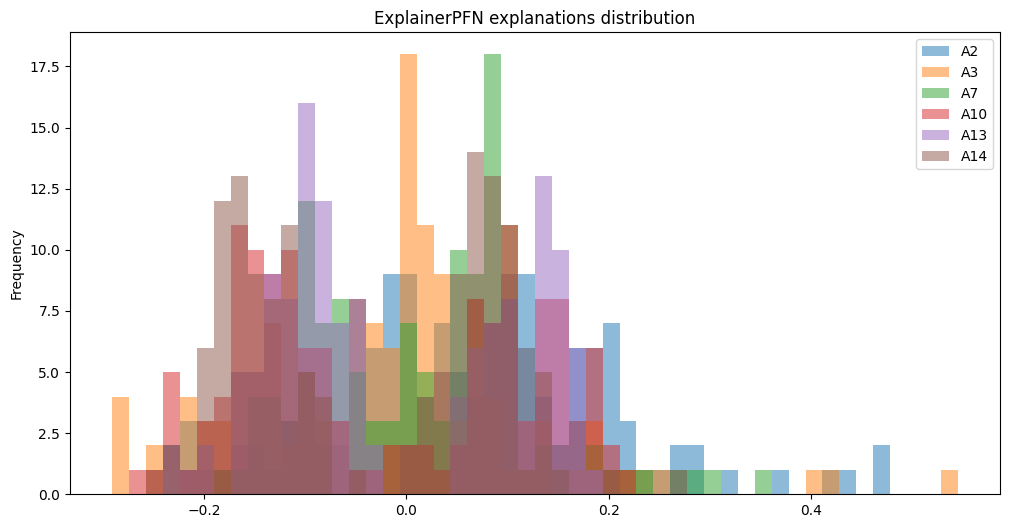

In [4]:
df_pfn_base = pd.DataFrame(explanations_corrected, columns=columns)
df_pfn_base.plot.hist(bins=50, alpha=.5, figsize=(12, 6), title="ExplainerPFN explanations distribution")

## Training different classifiers

In [5]:
mlp1 = MLPClassifier(
    max_iter=2000, alpha=0.05, learning_rate="invscaling", random_state=42
)
mlp1.fit(X_train, y_train)

mlp2 = MLPClassifier(
    max_iter=2000, alpha=0.005, learning_rate="invscaling", random_state=0
)
mlp2.fit(X_train, y_train)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

models = {"MLP1": mlp1, "MLP2": mlp2, "RF": rf, "LogReg": logreg}
predict_probas = {name: model.predict_proba(X_test)[:, 1] for name, model in models.items()}

In [6]:
# Get explanations from all models using SHAP
shap_explanations = {}
for name, model in models.items():
    print(f"Getting SHAP explanations for {name}...")
    xai = shap.Explainer(model=model.predict_proba, masker=X_train, algorithm="exact")
    shap_explanations[name] = xai(X_test).values[:, :, -1]

Getting SHAP explanations for MLP1...
Getting SHAP explanations for MLP2...
Getting SHAP explanations for RF...
Getting SHAP explanations for LogReg...


In [10]:
import numpy as np
from sklearn.linear_model import LinearRegression

df = pd.DataFrame(X_test, columns=columns)
df["target"] = y_test

# Get explanations from all models using ExplainerPFN
pfn_explanations = {}
pfn_explanations_corrected = {}
for name, model in models.items():
    print(f"Getting ExplainerPFN explanations for {name}...")
    # X_train_resampled, y_train_resampled = OverSamplingAugmentation(GeometricSMOTE(), random_state=42).fit_resample(X_train, y_train)

    xai = ExplainerPFN(model_path=PFN_MODEL_PATH, random_state=42)
    # xai.fit(X_train_resampled, model.predict_proba(X_train_resampled)[:, 1])
    xai.fit(X_train, model.predict_proba(X_train)[:, 1])
    pfn_explanations[name] = xai.predict(X_test, model.predict_proba(X_test)[:, 1])

    # pfn_explanations_corrected[name] = explanation_correction(
    #     pfn_explanations[name],
    #     predict_probas[name],
    #     model.predict_proba(X_train)[:, 1].mean(),
    #     adjust_std=True,
    # )

    pfn_explanations_corrected[name] = xai.apply_correction(
        predict_probas[name],
        pfn_explanations[name],
        kind=["statistical", "additive"],
    )

Getting ExplainerPFN explanations for MLP1...
Getting ExplainerPFN explanations for MLP2...
Getting ExplainerPFN explanations for RF...
Getting ExplainerPFN explanations for LogReg...


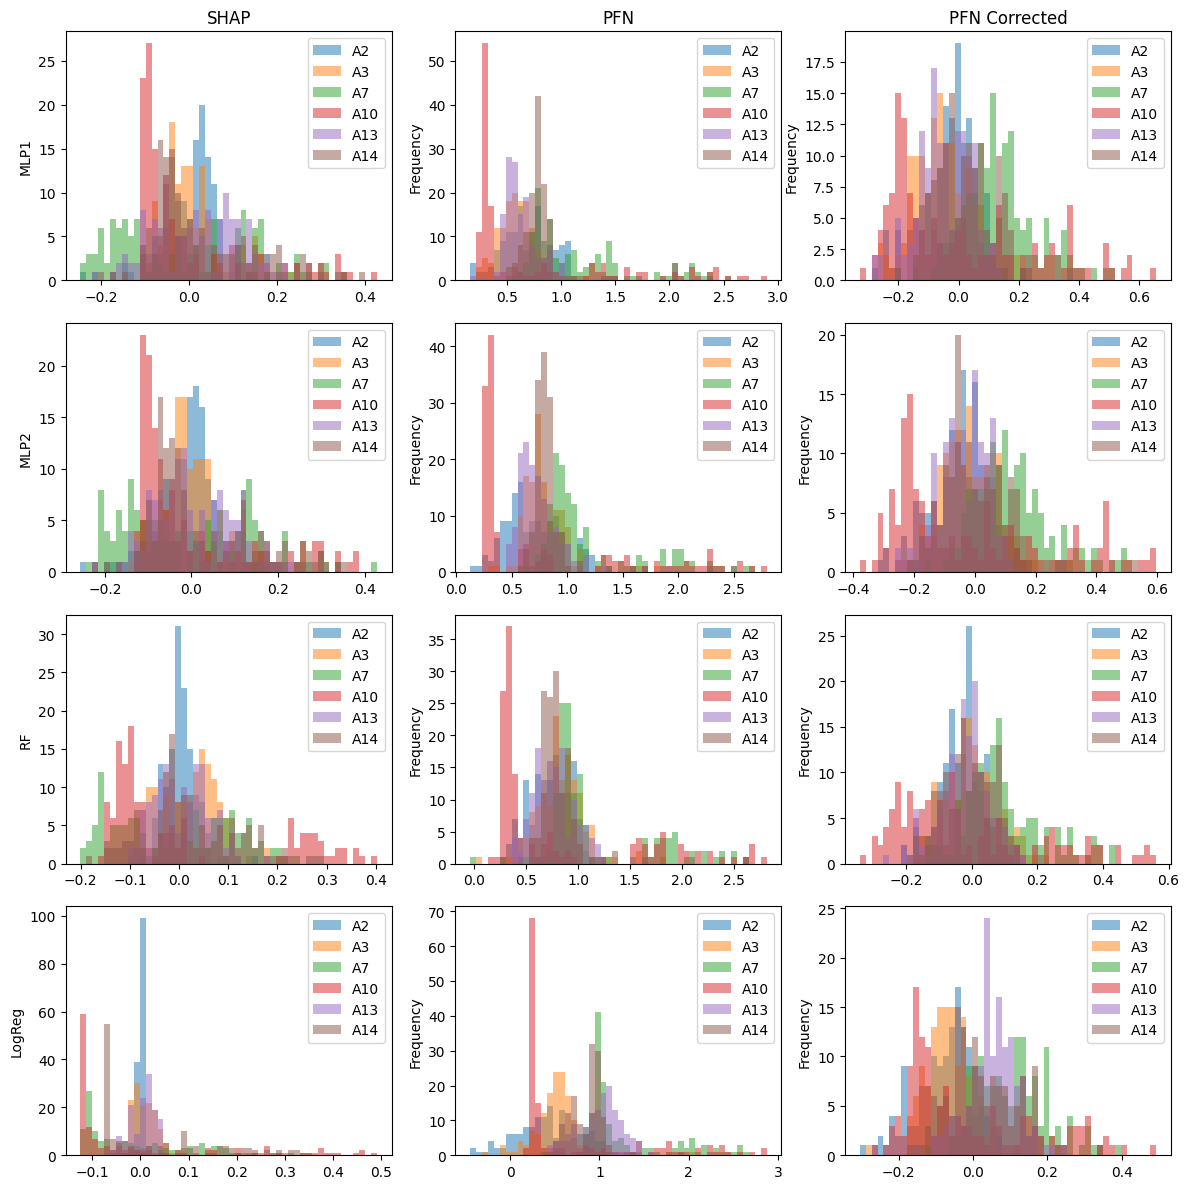

In [11]:
fig, axes = plt.subplots(4, 3, figsize=(12, 12))
for i, (model_name, model) in enumerate(models.items()):
    for j, (exp_type, exp) in enumerate(
        zip(
            ["SHAP", "PFN", "PFN Corrected"],
            [shap_explanations, pfn_explanations, pfn_explanations_corrected],
        )
    ):
        ax = pd.DataFrame(exp[model_name], columns=columns).plot.hist(
            bins=50,
            alpha=0.5,
            # figsize=(12, 6),
            ax=axes[i, j],
        )
        if j == 0:
            ax.set_ylabel(model_name)
        if i == 0:
            ax.set_title(f"{exp_type}")


plt.tight_layout()
plt.show()

In [12]:
from explainerpfn.metrics import kendall_agreement, jaccard_agreement, euclidean_agreement, explanation_sensitivity
from sklearn.metrics import mean_squared_error

In [13]:
jaccard_agreement(
    pd.DataFrame(shap_explanations["MLP1"]), 
    pd.DataFrame(pfn_explanations["MLP1"]), 
    n_features=2
).mean()

np.float64(0.3115942028985507)

In [14]:
# Use performance metrics for explanations
performance_metrics = {}
for model_name in models.keys():
    performance_metrics[model_name] = {}
    performance_metrics[model_name]["jaccard"] = jaccard_agreement(
        pd.DataFrame(shap_explanations[model_name], columns=columns), 
        pd.DataFrame(pfn_explanations_corrected[model_name], columns=columns), 
        n_features=2
    ).mean()
    performance_metrics[model_name]["kendall"] = kendall_agreement(
        pd.DataFrame(shap_explanations[model_name], columns=columns), 
        pd.DataFrame(pfn_explanations_corrected[model_name], columns=columns), 
    ).mean()

    performance_metrics[model_name]["euclidean"] = euclidean_agreement(
        pd.DataFrame(shap_explanations[model_name], columns=columns), 
        pd.DataFrame(pfn_explanations_corrected[model_name], columns=columns), 
        normalization=True
    ).mean()

    performance_metrics[model_name]["outcome_sensitivity"] = explanation_sensitivity(
        original_data=X_test,
        contributions=pd.DataFrame(pfn_explanations_corrected[model_name], columns=columns),
        rankings=predict_probas[model_name],
        n_neighbors=10,
    )[0]

    performance_metrics[model_name]["mse"] = mean_squared_error(
        shap_explanations[model_name], 
        pfn_explanations_corrected[model_name]
    )

pd.DataFrame(performance_metrics)

,MLP1,MLP2,RF,LogReg
jaccard,0.364734,0.381643,0.388889,0.371981
kendall,0.584058,0.568599,0.540580,0.588406
euclidean,0.437379,0.449946,0.462654,0.463587
outcome_sensitivity,0.606908,0.606473,0.544348,0.648116
mse,0.027205,0.026976,0.018834,0.017093


In [15]:
explanation_comparison_matrix = {}
methods = {"shap": shap_explanations, "pfn": pfn_explanations, "pfn corrected": pfn_explanations_corrected}
for method_name in methods.keys():
    explanation_comparison_matrix[method_name] = {}
    for model_name1 in models.keys():
        explanation_comparison_matrix[method_name][model_name1] = {}
        for model_name2 in models.keys():
            explanation_comparison_matrix[method_name][model_name1][model_name2] = euclidean_agreement(
                pd.DataFrame(methods[method_name][model_name1], columns=columns), 
                pd.DataFrame(methods[method_name][model_name2], columns=columns), 
                True
            ).mean()
    

In [16]:
pd.DataFrame(explanation_comparison_matrix["shap"])

,MLP1,MLP2,RF,LogReg
MLP1,1.000000,0.827396,0.708127,0.707297
MLP2,0.827396,1.000000,0.706174,0.707650
RF,0.708127,0.706174,1.000000,0.732235
LogReg,0.707297,0.707650,0.732235,1.000000


In [17]:
pd.DataFrame(explanation_comparison_matrix["pfn corrected"])

,MLP1,MLP2,RF,LogReg
MLP1,1.000000,0.792544,0.723017,0.687067
MLP2,0.792544,1.000000,0.754296,0.691457
RF,0.723017,0.754296,1.000000,0.660332
LogReg,0.687067,0.691457,0.660332,1.000000


In [18]:
def print_agreement(shap_values, pfn_values):
    print("Top positive")
    print("top-1:", (shap_values.argsort(axis=1)[:, -1:] == pfn_values.argsort(axis=1)[:, -1:]).all(axis=1).mean())
    print("top-2:", (shap_values.argsort(axis=1)[:, -2:] == pfn_values.argsort(axis=1)[:, -2:]).all(axis=1).mean())
    print("top-3:", (shap_values.argsort(axis=1)[:, -3:] == pfn_values.argsort(axis=1)[:, -3:]).all(axis=1).mean())
    print("top-4:", (shap_values.argsort(axis=1)[:, -4:] == pfn_values.argsort(axis=1)[:, -4:]).all(axis=1).mean())

    print("Top negative")
    print("top-1:", (shap_values.argsort(axis=1)[:, :1] == pfn_values.argsort(axis=1)[:, :1]).all(axis=1).mean())
    print("top-2:", (shap_values.argsort(axis=1)[:, :2] == pfn_values.argsort(axis=1)[:, :2]).all(axis=1).mean())
    print("top-3:", (shap_values.argsort(axis=1)[:, :3] == pfn_values.argsort(axis=1)[:, :3]).all(axis=1).mean())
    print("top-4:", (shap_values.argsort(axis=1)[:, :4] == pfn_values.argsort(axis=1)[:, :4]).all(axis=1).mean())

    print("Top absolute")
    print("top-1:", (np.abs(shap_values).argsort(axis=1)[:, -1:] == np.abs(pfn_values).argsort(axis=1)[:, -1:]).all(axis=1).mean())
    print("top-2:", (np.abs(shap_values).argsort(axis=1)[:, -2:] == np.abs(pfn_values).argsort(axis=1)[:, -2:]).all(axis=1).mean())
    print("top-3:", (np.abs(shap_values).argsort(axis=1)[:, -3:] == np.abs(pfn_values).argsort(axis=1)[:, -3:]).all(axis=1).mean())
    print("top-4:", (np.abs(shap_values).argsort(axis=1)[:, -4:] == np.abs(pfn_values).argsort(axis=1)[:, -4:]).all(axis=1).mean())

In [19]:
print_agreement(shap_explanations["LogReg"], pfn_explanations_corrected["LogReg"])

Top positive
top-1: 0.16666666666666666
top-2: 0.050724637681159424
top-3: 0.007246376811594203
top-4: 0.007246376811594203
Top negative
top-1: 0.47101449275362317
top-2: 0.021739130434782608
top-3: 0.007246376811594203
top-4: 0.0
Top absolute
top-1: 0.39855072463768115
top-2: 0.07971014492753623
top-3: 0.021739130434782608
top-4: 0.021739130434782608


In [20]:
for key in shap_explanations.keys():
    baseline = (np.sign(shap_explanations[key]) == 1).mean()
    agreement = (np.sign(shap_explanations[key]) == np.sign(pfn_explanations_corrected[key])).mean()
    print(f"Contribution direction agreement for {key}: {agreement} (baseline: {baseline})")

Contribution direction agreement for MLP1: 0.6304347826086957 (baseline: 0.46618357487922707)
Contribution direction agreement for MLP2: 0.6280193236714976 (baseline: 0.43719806763285024)
Contribution direction agreement for RF: 0.6111111111111112 (baseline: 0.5048309178743962)
Contribution direction agreement for LogReg: 0.6183574879227053 (baseline: 0.46980676328502413)


In [21]:

(np.sign(shap_explanations[key]) == np.sign(X_test - X_test.mean(axis=0))).mean()

np.float64(0.6533816425120773)

In [27]:
random_idxs = np.random.choice(X_test.shape[0], size=1, replace=False)
shap_explanations["MLP2"][random_idxs]

array([[ 3.74388108e-02,  1.24232770e-01, -7.56404821e-05,
        -6.76156831e-02,  4.77089051e-02,  3.57300031e-01]])

In [28]:
pfn_explanations_corrected["MLP2"][random_idxs]

array([[-0.00205169,  0.12609202,  0.19666541, -0.0288275 ,  0.0564618 ,
         0.13464718]])